# Random Forest classification on iris dataset

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier

In [2]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns= iris.feature_names)
df = pd.concat([df, pd.DataFrame(iris.target, columns= ["iris_species"])], axis = 1)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),iris_species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [8]:
pd.get_dummies(df)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),iris_species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [3]:
X, y = df.drop("iris_species", axis=1), df["iris_species"]
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: iris_species, dtype: int64

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

X_train.shape, X_test.shape

((100, 4), (50, 4))

In [6]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred[:10] # for guesses: 8/10

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1])

In [7]:
y_test[:10].values # facit

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1])

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.94      1.00      0.97        15
           2       1.00      0.94      0.97        16

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



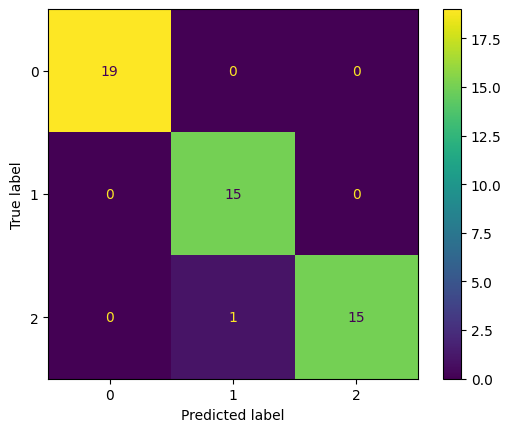

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print(classification_report(y_test, y_pred))
cm= confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()

In [9]:
model.feature_importances_

array([0.1297518 , 0.04418033, 0.37806036, 0.4480075 ])

In [10]:
X.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')

In [11]:
len(X.columns), len(model.feature_importances_)

(4, 4)

In [12]:
feature_importance = pd.DataFrame([X.columns, model.feature_importances_])
feature_importance

,0,1,2,3
0,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
1,0.129752,0.04418,0.37806,0.448008


In [13]:
feature_importance = feature_importance.T
feature_importance #.columns["Feature", "Importanc"]

,0,1
0,sepal length (cm),0.129752
1,sepal width (cm),0.04418
2,petal length (cm),0.37806
3,petal width (cm),0.448008


In [14]:
feature_importance.columns = ["Feature", "Importance"]

In [15]:
feature_importance

,Feature,Importance
0,sepal length (cm),0.129752
1,sepal width (cm),0.04418
2,petal length (cm),0.37806
3,petal width (cm),0.448008


In [16]:
feature_importance.sort_values(by="Importance", ascending=True)
feature_importance

,Feature,Importance
0,sepal length (cm),0.129752
1,sepal width (cm),0.04418
2,petal length (cm),0.37806
3,petal width (cm),0.448008


In [17]:
feature_importance["Importance"].sum()

np.float64(1.0)

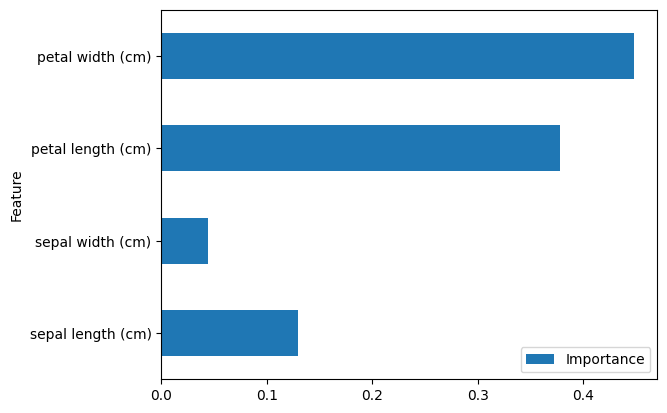

In [18]:
ax = feature_importance.plot(y="Importance", x="Feature", kind="barh")
#ax.invert_yaxis()